In [9]:
import plumed
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os
import matplotlib as mpl


/tmp/ipykernel_200035/2083952151.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/2083952151.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/2083952151.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` ins

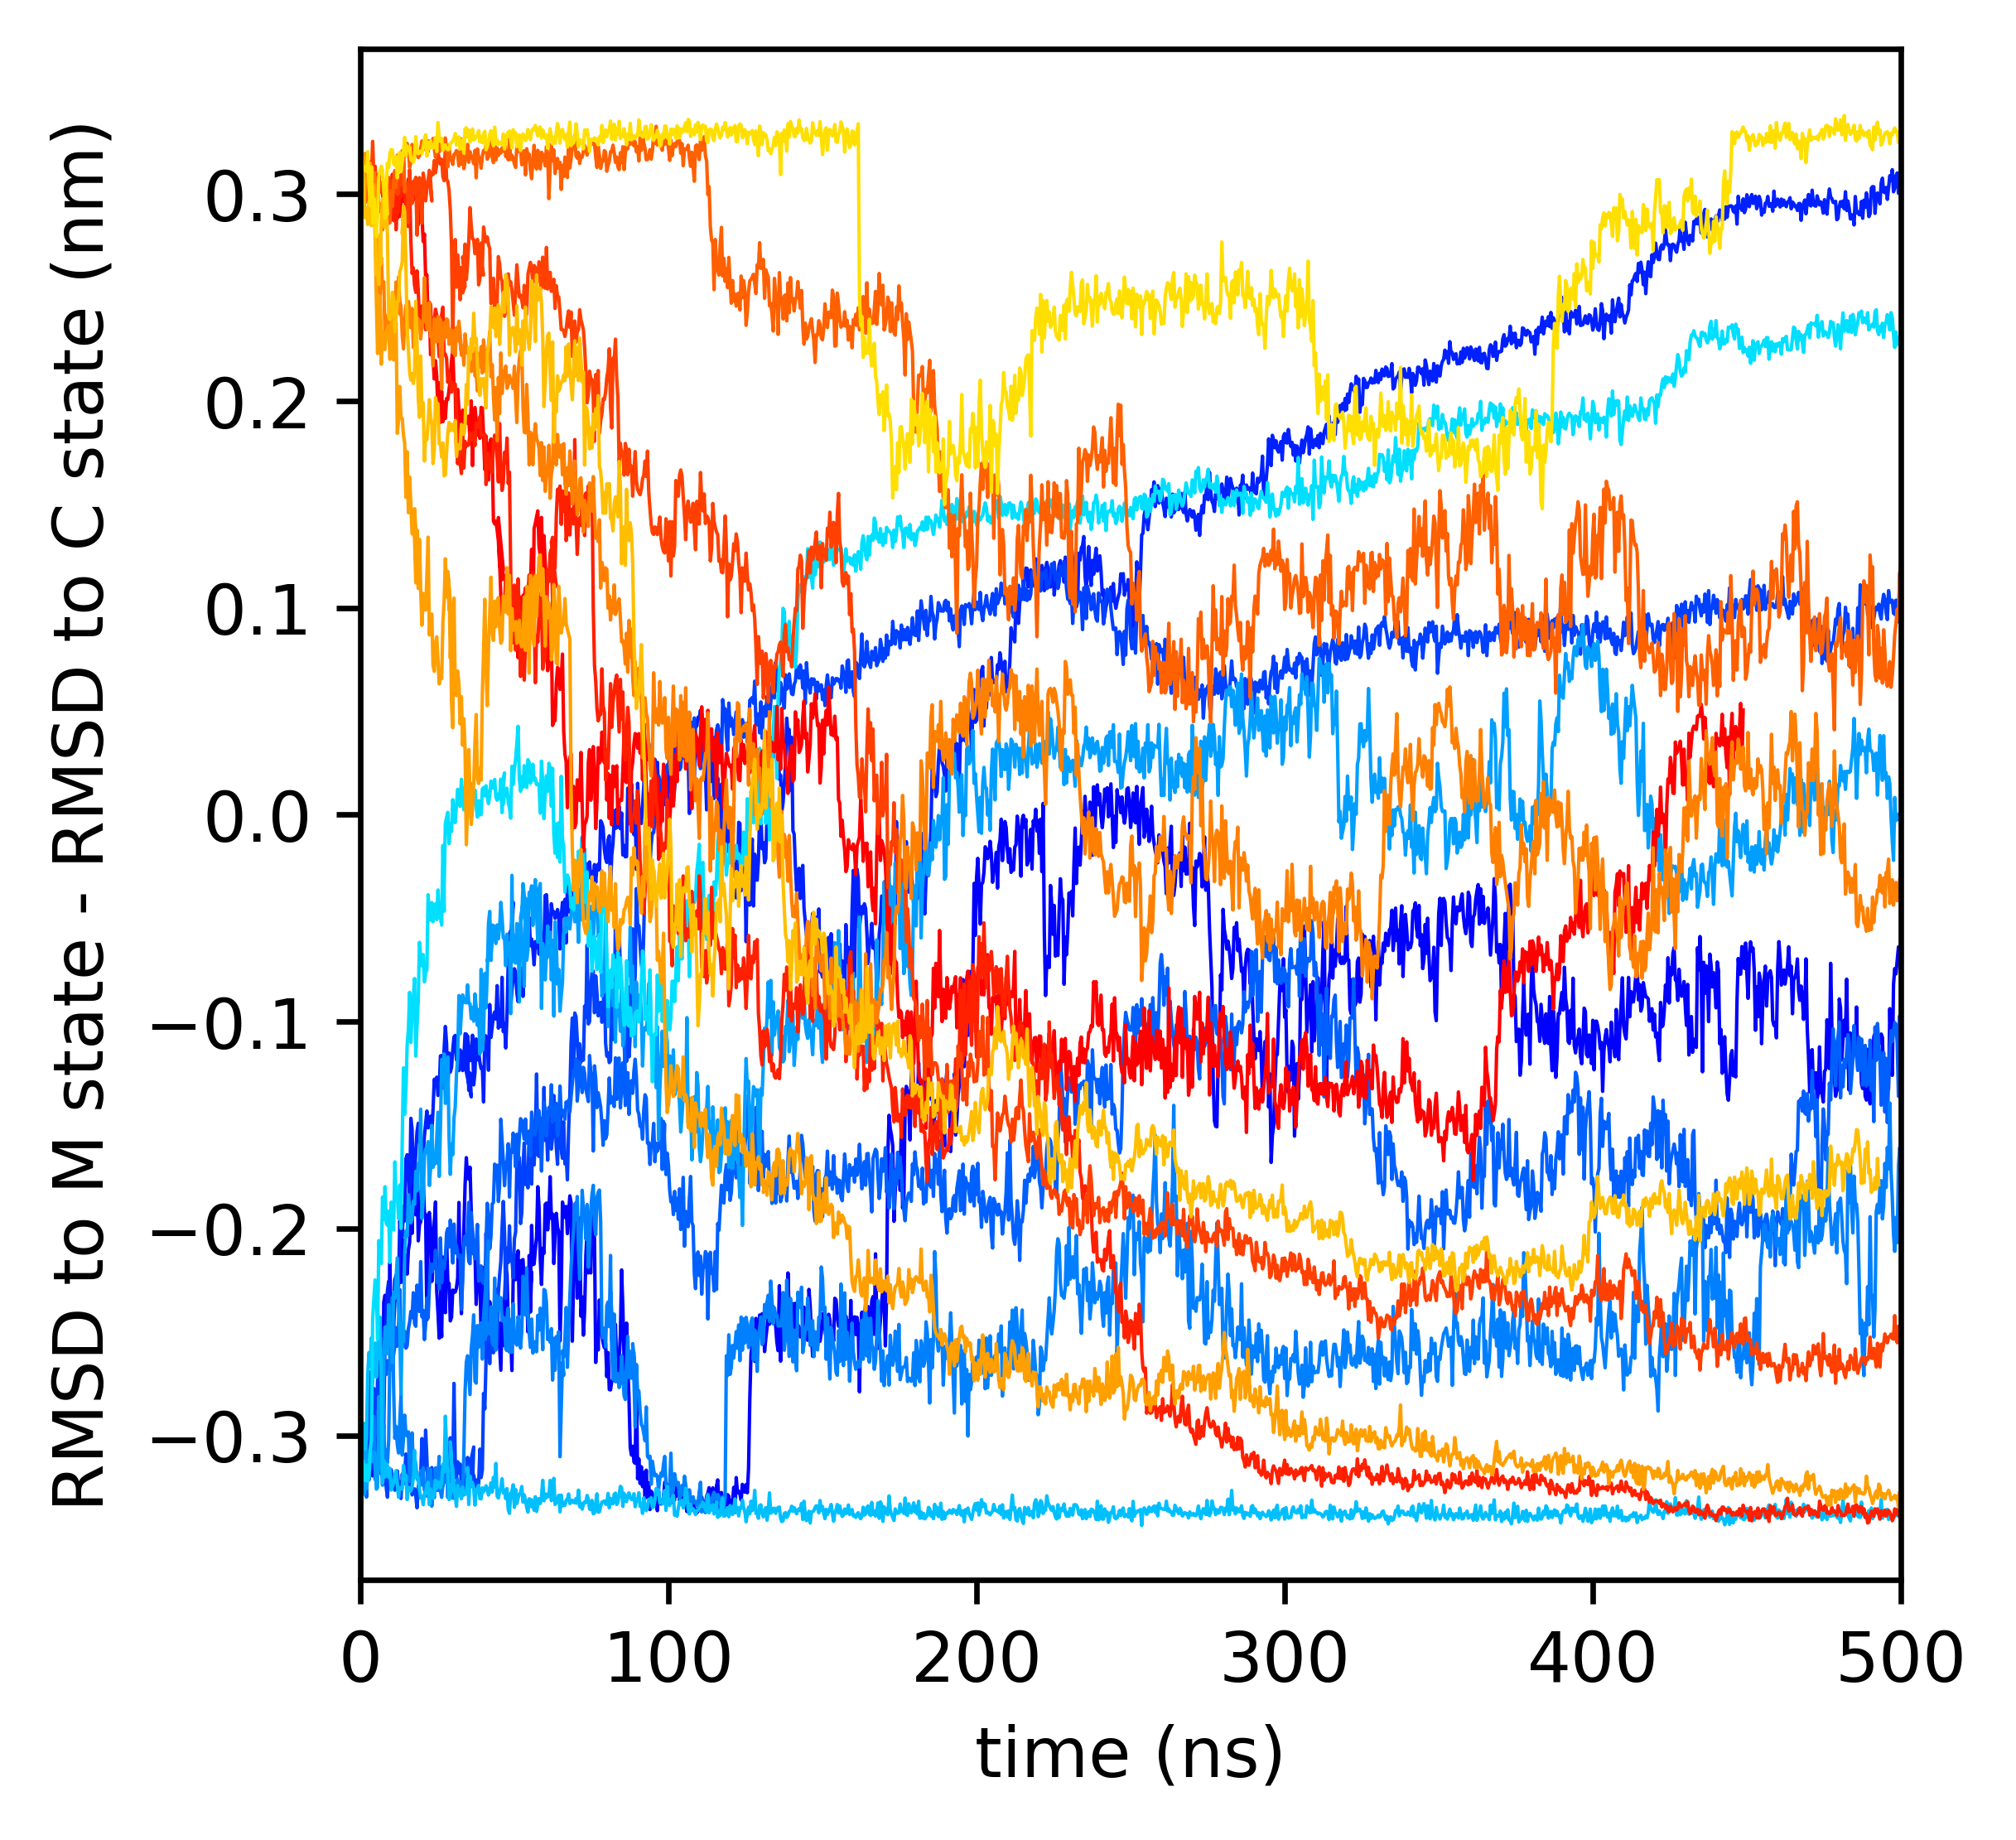

In [42]:
plt.figure(figsize=(4,4),dpi=600)

test_state = "c"
test_walker = -5

run_num = 4

nwalkers = 8
for init_state in ["c","m"]:
    for walker in range(nwalkers):
        if init_state == "c":
            infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{run_num}/run_{init_state}/COLVAR.{walker}"
        else:
            infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{run_num}/run_{init_state}/COLVAR.{walker}"

        colvar=plumed.read_as_pandas(infile)

        freq = 1

        time = list(colvar.time[::freq]*0.001*freq) #time in ns

        delta = list(colvar.pc_f1b[::freq])



        if init_state == test_state and walker == test_walker:
            plt.plot(time, delta, color = (0,0,0), linewidth=0.5)
        elif init_state == "c":
            plt.plot(time, delta, color = (0,walker/nwalkers,1), linewidth=0.5)
        elif init_state == "m":
            plt.plot(time, delta, color = (1,walker/nwalkers,0), linewidth=0.5)

plt.xlabel("time (ns)")
plt.ylabel("RMSD to M state - RMSD to C state (nm)")

plt.xlim(0, 500)
plt.ylim(-0.37,0.37)
plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/1877638611.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/1877638611.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/1877638611.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` ins

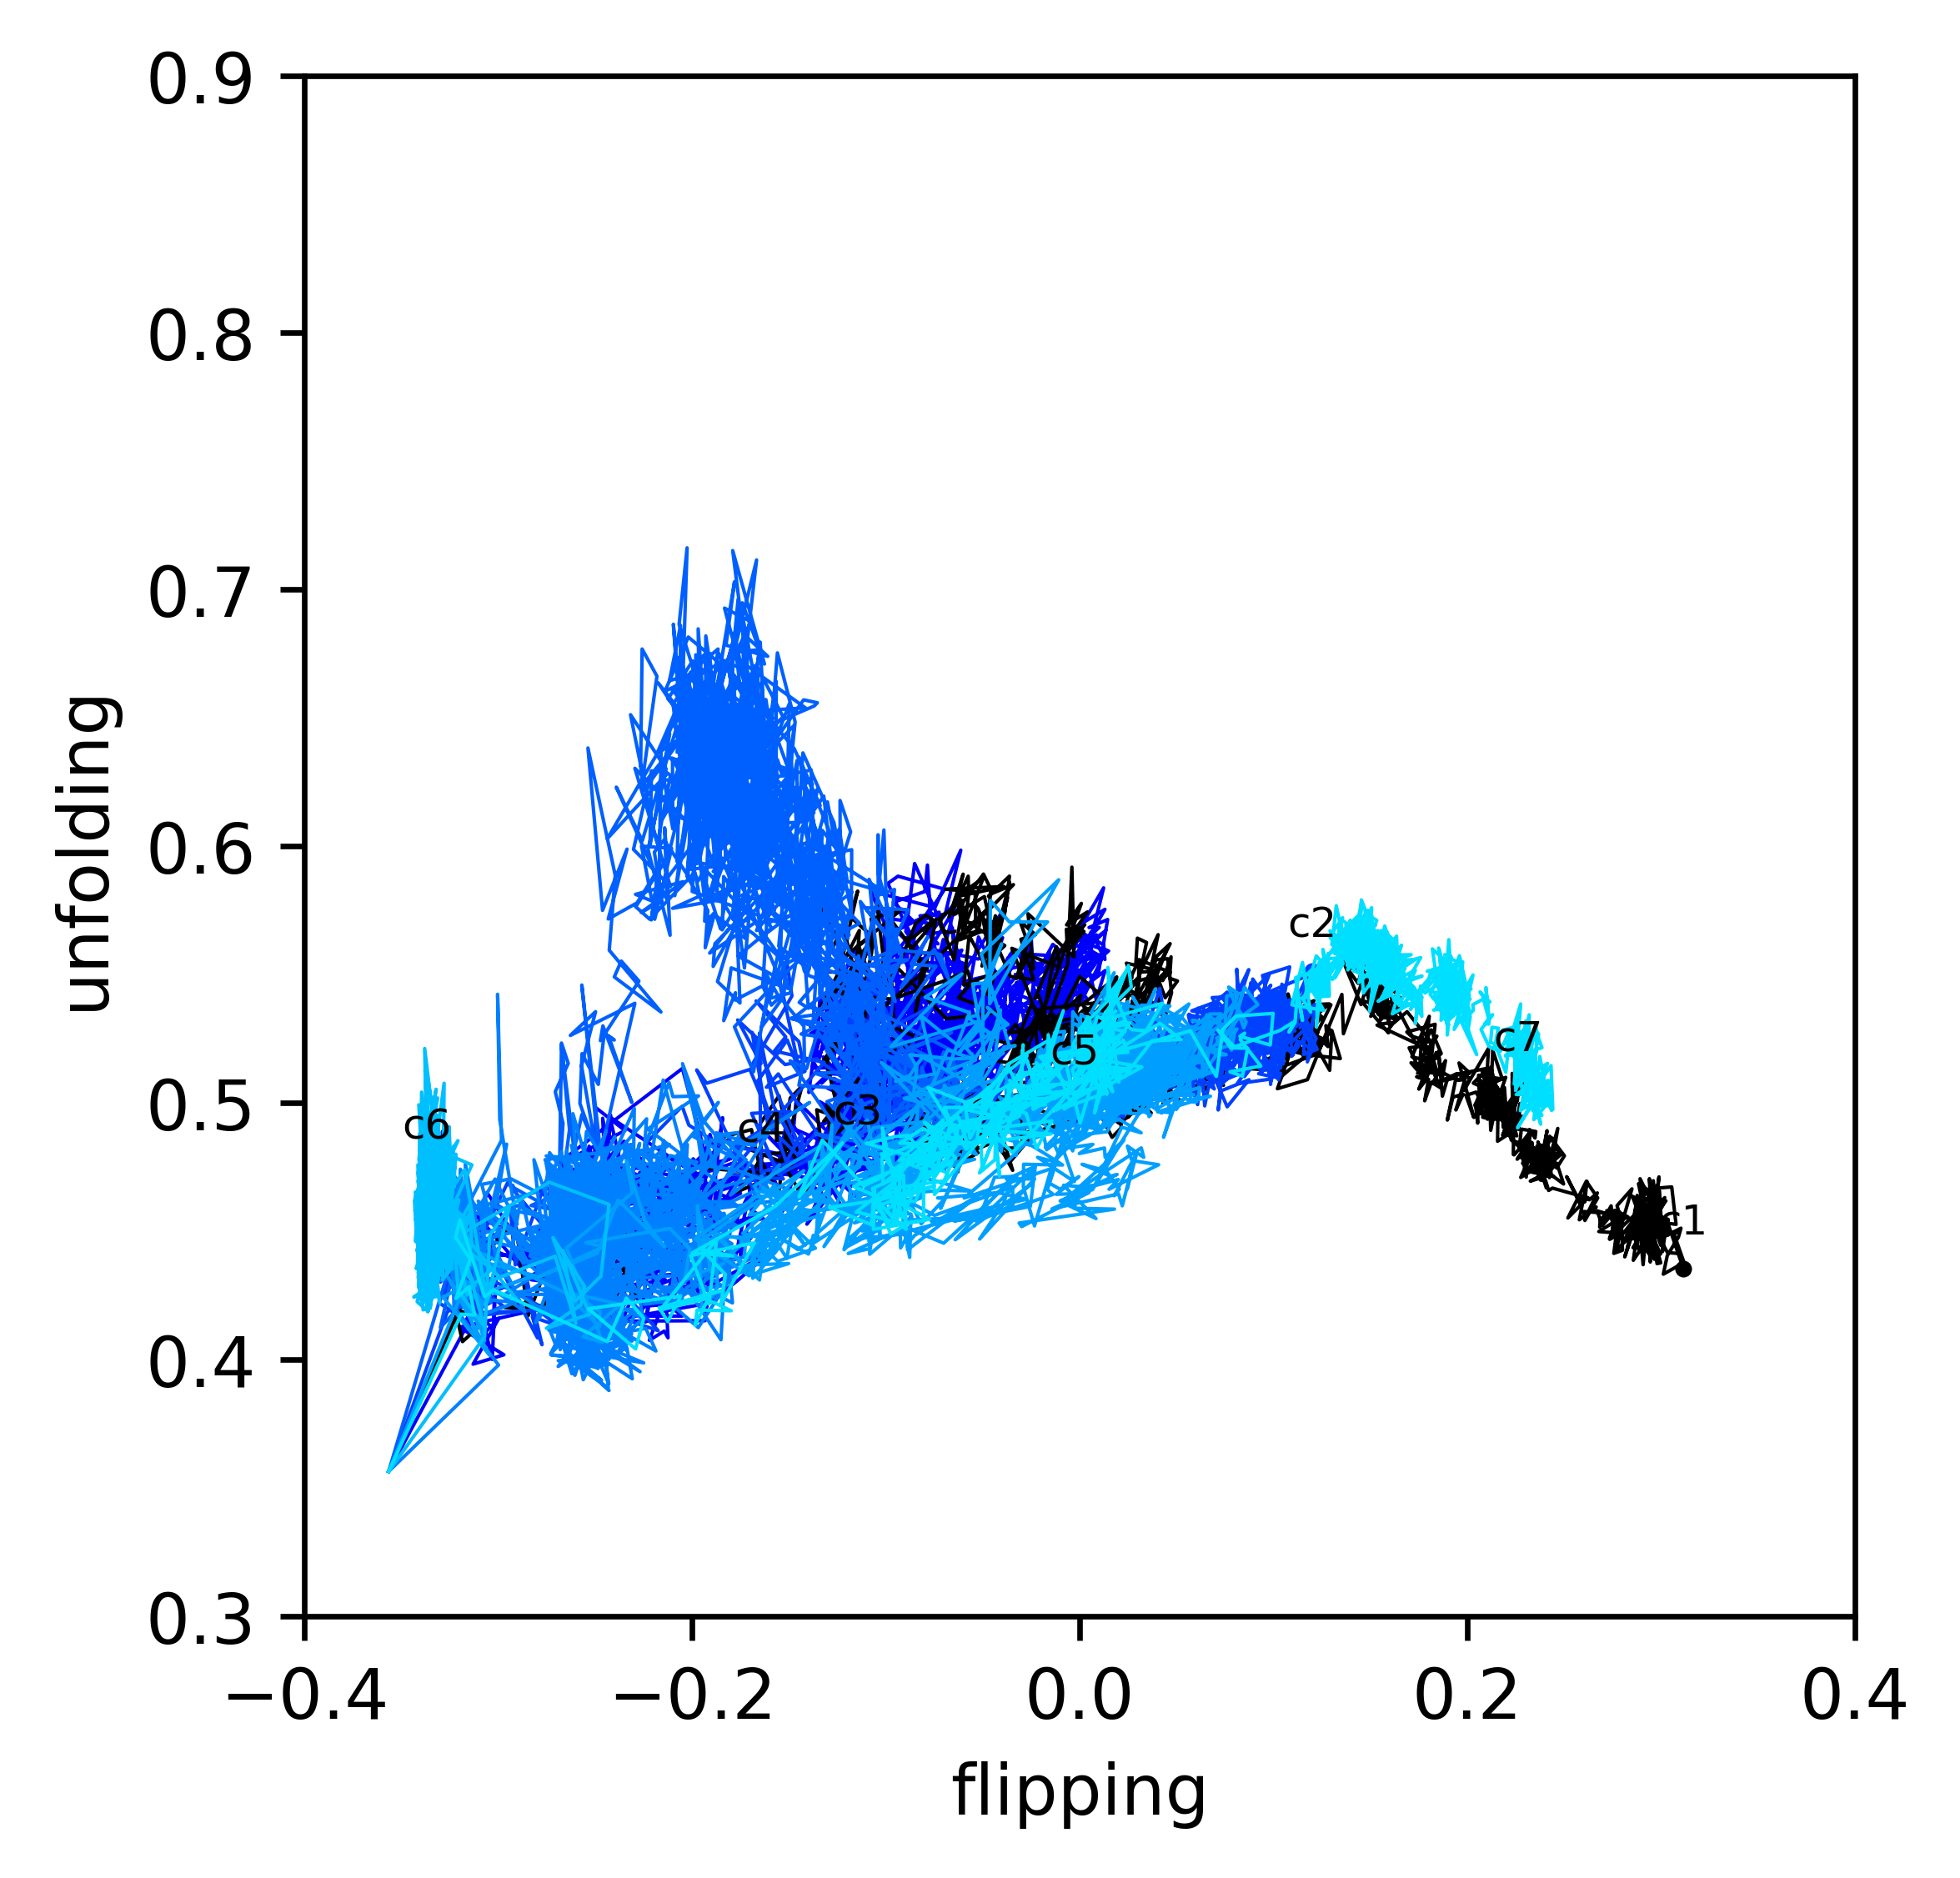

In [4]:
plt.figure(figsize=(4,4),dpi=600)

test_state = "c"
test_walker = 1
# run_num = 4

nwalkers = 8
for init_state in ["c"]:#,"m"]:
    for walker in range(nwalkers):
        if init_state == "c":
            infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{run_num}/run_{init_state}/COLVAR.{walker}"
        else:
            infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{run_num}/run_{init_state}/COLVAR.{walker}"

        colvar=plumed.read_as_pandas(infile)

        freq = 1

        delta = list(colvar.pc_f1b[::freq])
        pc_c = list(colvar.pc_fc[::freq])
        pc_m = list(colvar.pc_fm[::freq])

        sigma = [i+j for i,j in zip(pc_c,pc_m)]

        if init_state == test_state and walker == test_walker:
            color = (0,0,0)
        elif init_state == "c":
            color = (0,walker/nwalkers,1)
            #continue
        elif init_state == "m":
            color = (1,walker/nwalkers,0)
            #continue

        plt.plot(delta, sigma, color = color, linewidth=0.5)

        plt.scatter(delta[-1], sigma[-1], color = color, s=2)
        plt.annotate(f"{init_state}{walker}", (delta[-1], sigma[-1]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=6)
        continue

        #mark regular intervals along trajectory
        window_freq = len(list(colvar.pc_f1b))//32
        print(window_freq)

        wdelta = list(colvar.pc_f1b[::window_freq])
        wpc_c = list(colvar.pc_fc[::window_freq])
        wpc_m = list(colvar.pc_fm[::window_freq])

        wsigma = [i+j for i,j in zip(wpc_c,wpc_m)]

        print(f"{len(wdelta)} windows")

        plt.scatter(wdelta, wsigma, color = "red", s=2)


        #get regularly spaced points that are at least 0.03 nm apart in both dimensions
        time = list(colvar.time[::freq]*0.001*freq)

        coords = []
        times = []

        thresh = 0.03

        for t, (d,s) in enumerate(zip(delta, sigma)):
            farenough = True
            for c in coords:
                if abs(d - c[0]) < thresh and abs(s - c[1]) < thresh:
                    farenough = False
                    break

            if farenough or t == len(time)-1:
                times.append(time[t])
                print(f"{time[t]} ns")
                coords.append((d,s))

        print(f"found {len(coords)} points")
        plt.scatter([c[0] for c in coords], [c[1] for c in coords], color = "blue", s=2, zorder = 10000)



plt.xlabel("flipping")
plt.ylabel("unfolding")

plt.xlim(-0.4, 0.4)
plt.ylim(0.3, 0.9)
plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/2187172260.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_c = plumed.read_as_pandas(fesfile_c)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/2187172260.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_m = plumed.read_as_pandas(fesfile_m)


(0.0, 200.0)

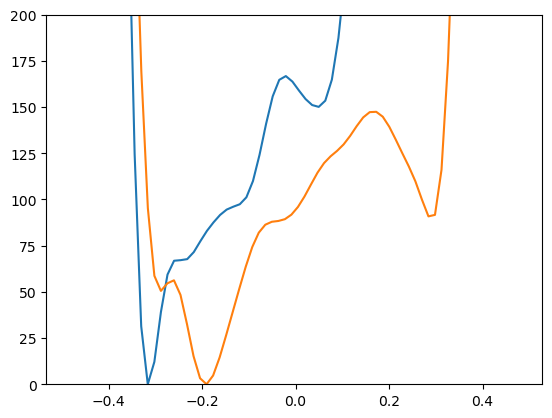

In [5]:
runnum=4
date="012126"
fesfile_c = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{runnum}/run_c/summed_hills/fes-{date}.dat"
fesfile_m = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{runnum}/run_m/summed_hills/fes-{date}.dat"


#read and plot metadynamics potential
data_c = plumed.read_as_pandas(fesfile_c)
c_pc_f1b = list(data_c["pc_f1b"])
c_energy = list(data_c["file.free"])

plt.plot(c_pc_f1b, c_energy)

data_m = plumed.read_as_pandas(fesfile_m)
m_pc_f1b = list(data_m["pc_f1b"])
m_energy = list(data_m["file.free"])
plt.plot(m_pc_f1b, m_energy)

plt.ylim(0,200)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` ins

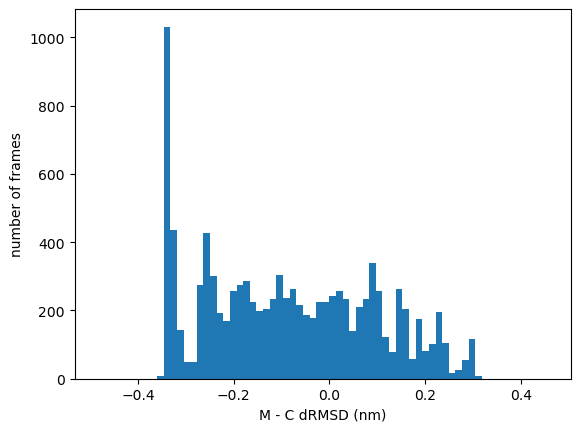

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3017046951.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` ins

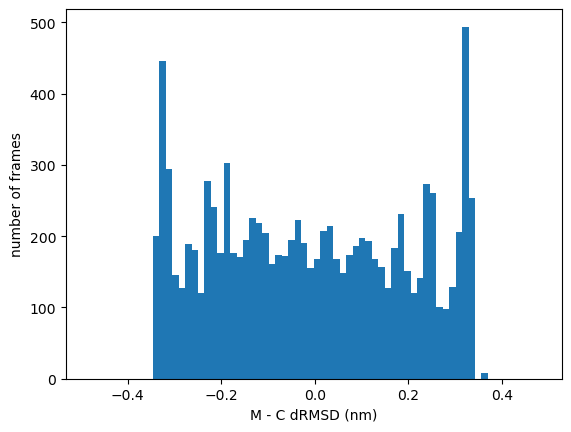

In [6]:



nwalkers = 8
for init_state in ["c","m"]:

    delta_all = []
    #sigma_all = []

    for walker in range(nwalkers):
        infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/run_{init_state}/COLVAR.{walker}"
        #infile = f"/home/jonathan/Documents/grabelab/aac1-ucp1/aac1/trajectories/plumed_tests/plumed/sys{system}/mwm{runnum}/{walker}/COLVAR"
        colvar=plumed.read_as_pandas(infile)

        freq = 1

        delta = list(colvar.pc_f1b[::freq])

        pc_c = list(colvar.pc_fc[::freq])
        pc_m = list(colvar.pc_fm[::freq])
        sigma = [i+j for i,j in zip(pc_c,pc_m)]

        delta_all+=delta
        #sigma_all+=sigma


    if init_state == "c":
        minx = delta_all[0]
    else:
        minx = -delta_all[0]
    #plt.figure(figsize=(4,4),dpi=600)
    if init_state == "c":
        nbins = len(c_pc_f1b)
        min_pc = min(c_pc_f1b)
        max_pc = max(c_pc_f1b)
    elif init_state == "m":
        nbins = len(m_pc_f1b)
        min_pc = min(m_pc_f1b)
        max_pc = max(m_pc_f1b)
    plt.hist(delta_all, bins=nbins, range=[min_pc, max_pc])

    plt.xlabel("M - C dRMSD (nm)")
    plt.ylabel("number of frames")
    plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anacond

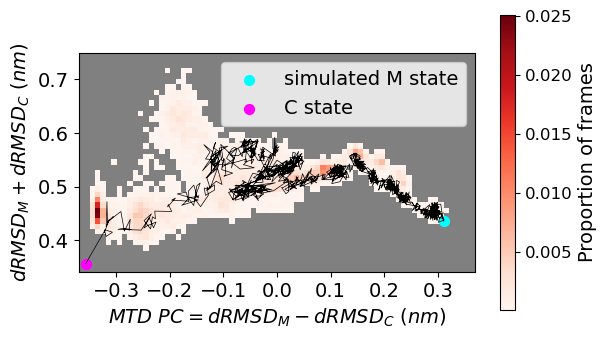

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_200035/3463604442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` ins

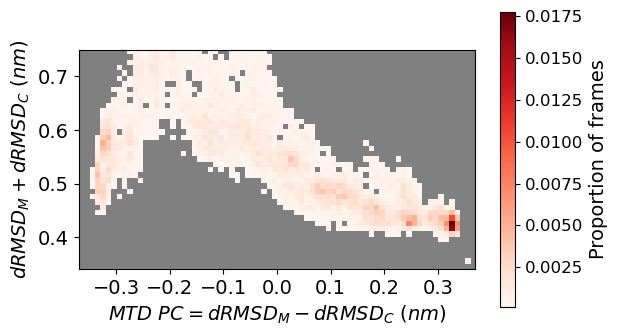

In [70]:
test_state = "c"
test_walker = 1

fig = plt.figure()
ax = fig.add_subplot(111)

plt.rcParams['font.size'] = 14


nwalkers = 8
for init_state in ["c","m"]:

    delta_all = []
    sigma_all = []

    for walker in range(nwalkers):
        infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/run_{init_state}/COLVAR.{walker}"
        #infile = f"/home/jonathan/Documents/grabelab/aac1-ucp1/aac1/trajectories/plumed_tests/plumed/sys{system}/mwm{runnum}/{walker}/COLVAR"
        colvar=plumed.read_as_pandas(infile)

        freq = 1

        delta = list(colvar.pc_f1b[::freq])

        pc_c = list(colvar.pc_fc[::freq])
        pc_m = list(colvar.pc_fm[::freq])
        sigma = [i+j for i,j in zip(pc_c,pc_m)]

        delta_all+=delta
        sigma_all+=sigma

        if walker == test_walker and init_state == test_state:
            plt.plot(delta, sigma, color = (0,0,0), linewidth=0.5, label="_nolegend_")
            plt.scatter(delta[-1], sigma[-1], color = "cyan", s=50, label = "simulated M state")
            plt.scatter(delta[0], sigma[0], color = "magenta", s=50, label = "C state")
            plt.legend()

    # if init_state == "c":
    #     minx = delta_all[0]
    # else:
    #     minx = -delta_all[0]

    range1 = [[-0.37,0.37],[0.34,0.75]]

    histdata = np.histogram2d(np.array(delta_all), np.array(sigma_all), bins=(74,41), range = range1)
    
    hdata = histdata[0].T/np.sum(histdata[0]) #normalize histogram to get probability density

    # mask regions with no sampling
    masked_hdata = np.ma.masked_where(hdata == 0, hdata)
    cmap = mpl.colormaps.get_cmap("Reds").copy()
    labelcolor = "black"
    cblabel = f"Proportion of frames"

    #set color for regions with no sampling
    cmap.set_bad(color='grey')




    im = plt.imshow(masked_hdata, extent=range1[0]+range1[1], cmap = cmap, origin = "lower") #, vmin = -13, vmax = 13)
    cb = fig.colorbar(im, label = cblabel, shrink=0.8)
    cb.ax.tick_params(labelsize=12)
    #cb.ax.set_xlim(0,0.025) #this runs but does nothing

    #cb.ax.set_xlim(0, 0.03)
    plt.xticks([-0.3,-0.2,-0.1,0,0.1,0.2,0.3])

    # delta_ma = np.ma.masked_where(np.array(delta_all) > 0, np.array(delta_all))
    # sigma_ma = np.ma.masked_where(np.array(sigma_all) > 0, np.array(sigma_all))

    # #plt.figure(figsize=(4,4),dpi=600)
    # plt.hist2d(delta_ma, sigma_ma, bins=(50,50), range=[[minx,-minx],[sigma_all[0],0.75]])

    plt.xlabel(r"$MTD\ PC = dRMSD_M-dRMSD_C\ (nm)$", fontsize=14)
    plt.ylabel(r"$dRMSD_M+dRMSD_C\ (nm)$", fontsize=14)
    
    plt.savefig(f"run4_{init_state}_histogram_and_reactive_trj.png", dpi=600)
    
    plt.show()